# Exponential Smoothing & Holt-Winters Forecasting
### Goal: Build up from the simplest possible forecast to a full Holt-Winters model — step by step

---

We explore a different family of forecasting methods called **Exponential Smoothing**.

### The big idea

Instead of treating all past data equally, exponential smoothing gives **more weight to recent observations** and less weight to older ones. The further back in time a value is, the less influence it has on the forecast.

### The progression we will follow

| Method | What it handles |
|---|---|
| **Naive forecast** | Nothing — just repeats the last value |
| **Simple average** | Level only (assumes data is flat) |
| **Moving average** | Level only, but focuses on recent data |
| **Simple Exponential Smoothing** | Level only, but weights recent data more |
| **Double Exponential Smoothing** | Level + Trend |
| **Triple Exponential Smoothing (Holt-Winters)** | Level + Trend + Seasonality |

Each method fixes a weakness of the one before it.

### Dataset
The same **Airline Passengers** dataset

---
## Step 1 — Install Libraries

In [ ]:
# Install all libraries needed for this notebook (if needed)

# !pip install pandas numpy matplotlib statsmodels scikit-learn

---
## Step 2 — Import Libraries

In [1]:
# pandas — for working with tables of data
import pandas as pd

# numpy — for numerical calculations
import numpy as np

# matplotlib — for drawing charts
import matplotlib.pyplot as plt

# statsmodels — contains the exponential smoothing models
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# scikit-learn — for measuring prediction accuracy
from sklearn.metrics import mean_absolute_error, r2_score

# Hide unimportant warning messages
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 3 — Load and Prepare the Data

We use the same Airline Passengers dataset as the ARIMA notebook.  
The preparation steps are the same: convert dates, set the index, confirm the frequency.

In [ ]:
# Load the Airline Passengers dataset from the same online source as the ARIMA notebook

url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTD-VBPkHgph0AWNSd0ZvAyJ098KmGmGjvWaNABAr2xFpArAW3-jv0ZeU2cmolDlFLUbWqHvsnXaWML/pub?gid=1463613835&single=true&output=csv'

df = pd.read_csv(url)

print("Dataset loaded!")
print("First 5 rows:")
print(df.head())

Dataset loaded!
Number of rows: 144

First 5 rows:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [3]:
# Convert the Month column from text to a proper date
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as the index (row label) — required for time series models
df = df.set_index('Month')

# Tell Python this is monthly data
df.index = pd.DatetimeIndex(df.index.values, freq=df.index.inferred_freq)

print("Data prepared.")
print("Date range:", df.index.min(), "to", df.index.max())
print("Frequency:", df.index.freq)
print(df.head())

Data prepared.
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Frequency: <MonthBegin>
            Passengers
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


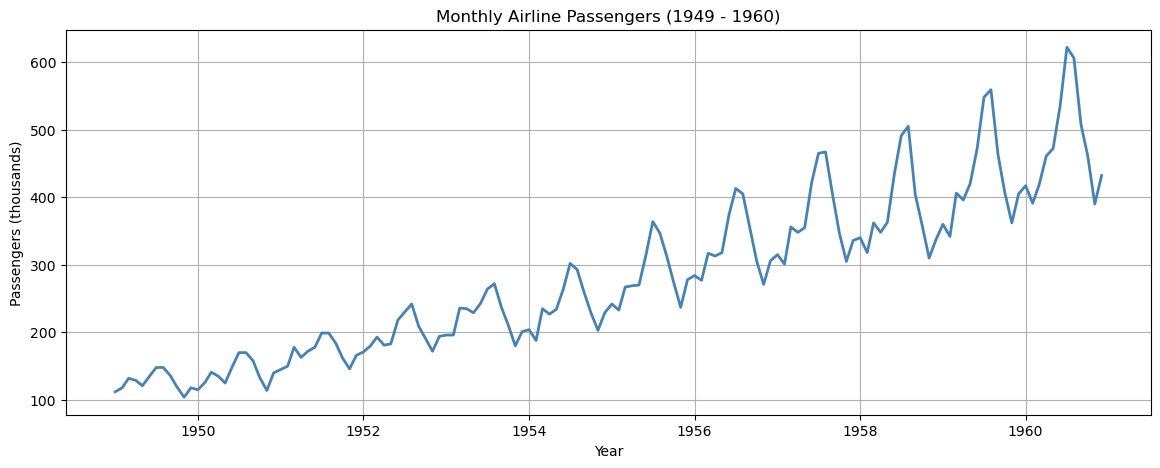

In [4]:
# Plot the raw data so we can see what we are working with

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Passengers'], color='steelblue', linewidth=2)
plt.title('Monthly Airline Passengers (1949 - 1960)')
plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.grid(True)
plt.show()

# Key observations:
# 1. TREND — the line climbs steadily upward over 12 years
# 2. SEASONALITY — every year has a summer peak (July/August) and a winter dip
# 3. GROWING VARIANCE — the seasonal swings get bigger each year
# These three features will each be handled by a different layer of the Holt-Winters model

---
## Step 4 — Train / Test Split

We always evaluate forecasting models on data they have **never seen**.  
We hold out the last 24 months (2 years) as the test set, a larger window than ARIMA  
so we can see how each method handles multi-step forecasting.

In [5]:
# Hold out the last 24 months for testing
train = df[:-24]
test  = df[-24:]

print("Training set:", len(train), "months")
print("  From:", train.index.min().strftime('%Y-%m'), "to", train.index.max().strftime('%Y-%m'))

print("Test set:", len(test), "months")
print("  From:", test.index.min().strftime('%Y-%m'), "to", test.index.max().strftime('%Y-%m'))

Training set: 120 months
  From: 1949-01 to 1958-12
Test set: 24 months
  From: 1959-01 to 1960-12


In [ ]:
# Helper function we will use this to score every model we build
# It prints R² and MAE, and draws the actual vs predicted chart

def evaluate(model_name, actual_train, actual_test, predictions):

    r2  = r2_score(actual_test, predictions)
    mae = mean_absolute_error(actual_test, predictions)
    pct = (mae / actual_test.mean()) * 100

    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(actual_train.index, actual_train,
             label='Training Data', color='steelblue', linewidth=2)
    plt.plot(actual_test.index, actual_test,
             label='Actual (Test)', color='green', linewidth=2)
    plt.plot(actual_test.index, predictions,
             label='Forecast', color='red', linewidth=2, linestyle='--')
    plt.title(model_name + ' — Actual vs Forecast')
    plt.xlabel('Date')
    plt.ylabel('Passengers (thousands)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Scores
    print("Results for:", model_name)
    print("  R² Score:", round(r2, 4), "  (closer to 1.0 is better)")
    print("  MAE:     ", round(mae, 2), "thousand passengers")
    print("  Error %: ", round(pct, 2), "% of average actual")
    print()

print("evaluate() function ready.")

evaluate() function ready.


---
## Part A — Naive Forecast (the starting point)

Before building any real model, we set a **baseline** using the simplest possible forecast.

### What is a naive forecast?
It assumes that tomorrow will be exactly the same as today.  
Every future value is simply the last observed value repeated.

**Formula:** Forecast(t) = Actual(t-1)

This is our benchmark. Any model we build must beat this to be worth using.

Last training value (our naive forecast): 337
This single value will be repeated for all 24 test months



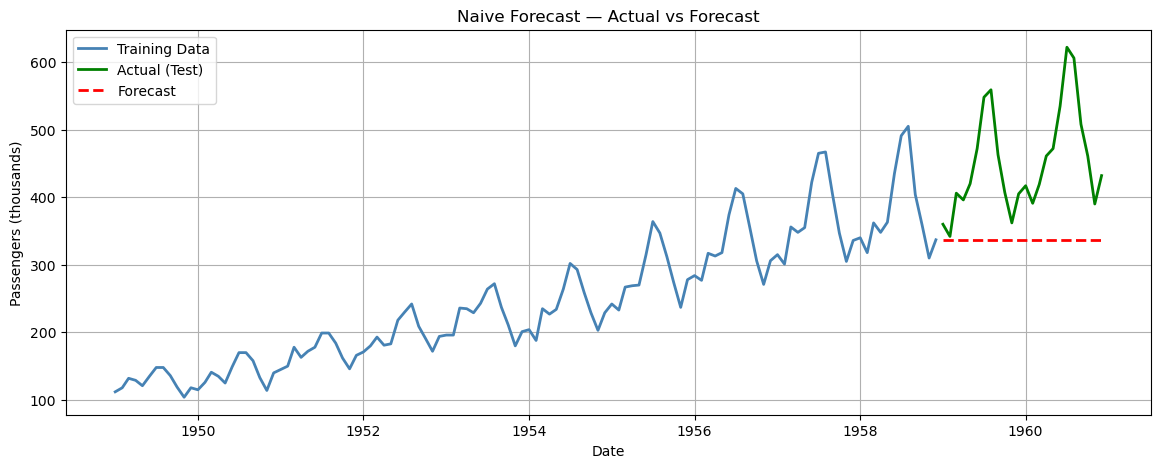

Results for: Naive Forecast
  R² Score: -2.3818   (closer to 1.0 is better)
  MAE:      115.25 thousand passengers
  Error %:  25.48 % of average actual



In [7]:
# The naive forecast repeats the last training value for every test month
last_value = train['Passengers'].iloc[-1]

naive_predictions = pd.Series(
    [last_value] * len(test),
    index=test.index
)

print("Last training value (our naive forecast):", last_value)
print("This single value will be repeated for all", len(test), "test months")
print()

evaluate('Naive Forecast', train['Passengers'], test['Passengers'], naive_predictions)

# Notice: the flat red line completely misses both the trend and the seasonal peaks
# This is the worst possible result — but it gives us something to compare against

---
## Part B — Simple Average

### What is the simple average forecast?
Instead of using just the last value, we average **all** past values and use that as the forecast.

**Formula:** Forecast(t) = Mean of all past values

This gives every historical observation equal weight whether it happened last month or 10 years ago.  
It is more stable than the naive forecast but still cannot capture trend or seasonality.

Average of all training values: 245.91



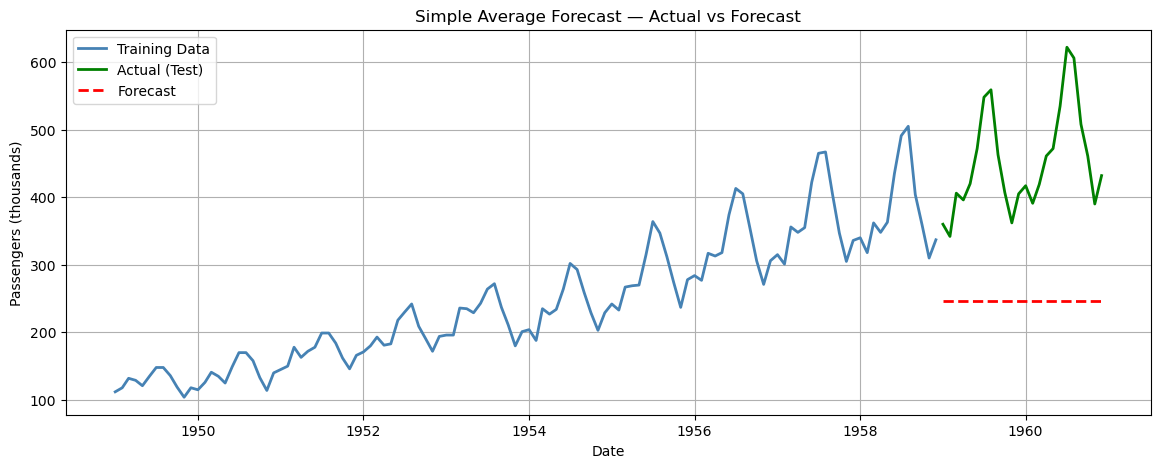

Results for: Simple Average Forecast
  R² Score: -7.6348   (closer to 1.0 is better)
  MAE:      206.34 thousand passengers
  Error %:  45.63 % of average actual



In [8]:
# The simple average forecast uses the mean of all training values
average_value = train['Passengers'].mean()

average_predictions = pd.Series(
    [average_value] * len(test),
    index=test.index
)

print("Average of all training values:", round(average_value, 2))
print()

evaluate('Simple Average Forecast', train['Passengers'], test['Passengers'], average_predictions)

# The red line is still flat — it ignores the upward trend
# But it is slightly better positioned than the naive forecast
# because it uses more information (all past values, not just the last one)

---
## Part C — Moving Average

### What is a moving average forecast?
Instead of averaging ALL past data, we only average the **most recent N observations**.  
The window "moves" forward in time.

**Formula:** Forecast(t) = Mean of the last N values

The key choice is the **window size (N)**:
- Small window (e.g. 3 months) → reacts quickly to recent changes, but noisy
- Large window (e.g. 12 months) → smoother but slower to react

For forecasting, the moving average makes one forecast and repeats it flat —  
it does not extrapolate a trend into the future.

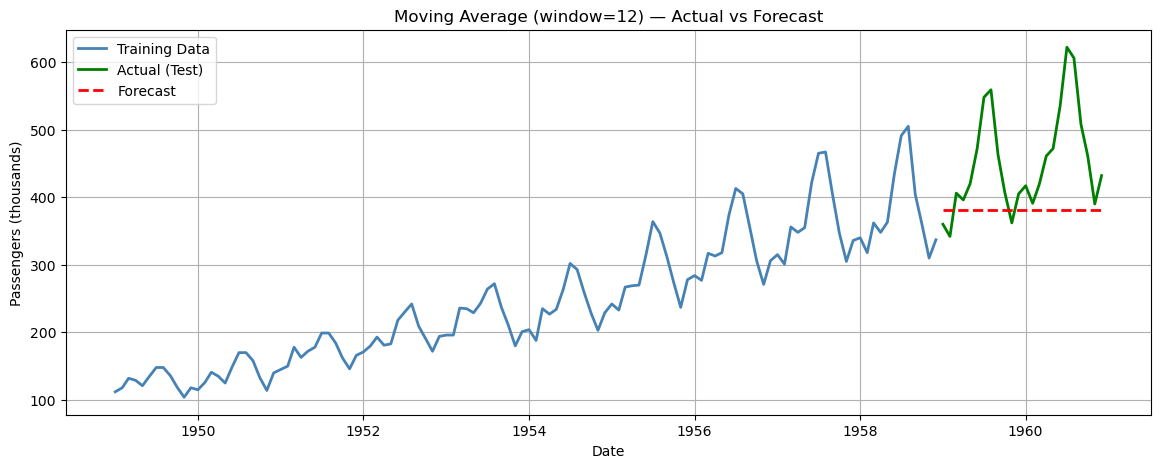

Results for: Moving Average (window=12)
  R² Score: -0.9103   (closer to 1.0 is better)
  MAE:      77.83 thousand passengers
  Error %:  17.21 % of average actual



In [10]:
# Use window=12 as our chosen moving average (one full year of recent data)
recent_12 = train['Passengers'].iloc[-12:]
ma12_value = recent_12.mean()

ma12_predictions = pd.Series(
    [ma12_value] * len(test),
    index=test.index
)

evaluate('Moving Average (window=12)', train['Passengers'], test['Passengers'], ma12_predictions)

# Better than the simple average because it focuses on recent data
# Still flat — no trend, no seasonality
# The progression so far: Naive → Simple Avg → Moving Avg
# Each step uses smarter averaging, but none can project a trend forward

---
## Part D — Weighted Moving Average → Simple Exponential Smoothing

### The problem with moving averages
Moving averages treat all N observations equally.  
But data from 12 months ago should probably count for less than data from last month.

### Weighted Moving Average
We can assign **different weights** to each past observation.  
More recent = higher weight.  
For example: last month gets weight 0.4, two months ago gets 0.3, three months ago gets 0.3.

### Simple Exponential Smoothing (SES) — the elegant solution
Instead of manually picking weights, SES uses a **formula** that automatically gives  
exponentially decreasing weights as you go further back in time.

**Formula:**  
Forecast(t) = α × Actual(t-1) + (1 - α) × Forecast(t-1)

The key parameter is **alpha (α)**, which controls how fast the weights fade:

| Alpha value | Behaviour |
|---|---|
| α close to 1 (e.g. 0.9) | Weights drop off very fast → model reacts quickly to recent data |
| α close to 0 (e.g. 0.1) | Weights fade slowly → model is more stable, less reactive |

Think of α as the "memory" dial:  
- High α = short memory (only cares about the very recent past)  
- Low α = long memory (older data still matters a lot)

> **Important limitation:** SES only models the **level** (average).  
> It cannot capture trend or seasonality — those require the next two methods.

Manual Weighted Moving Average:
  Last 3 values (newest first): [337 310 359]
  Weights applied: [0.5, 0.3, 0.2]
  Weighted forecast: 333.3



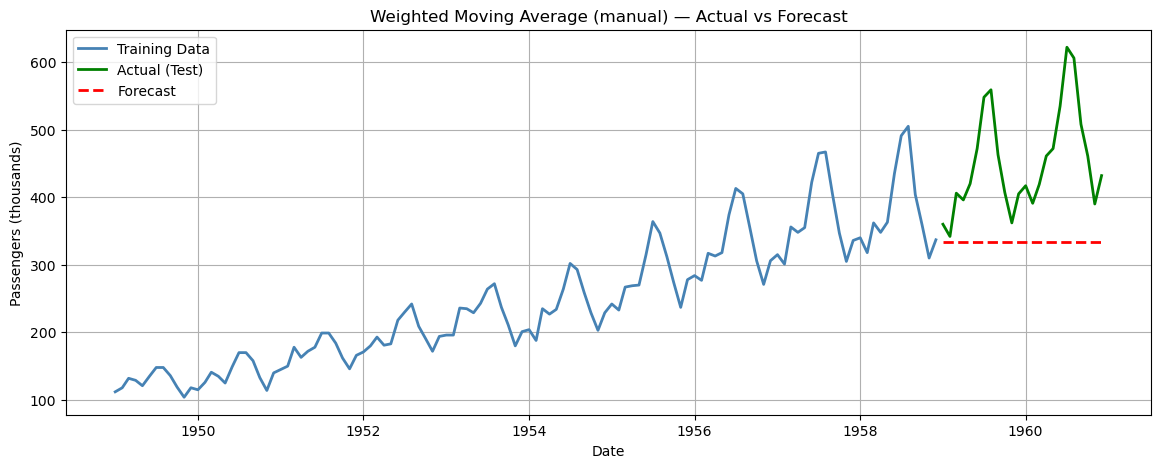

Results for: Weighted Moving Average (manual)
  R² Score: -2.5372   (closer to 1.0 is better)
  MAE:      118.95 thousand passengers
  Error %:  26.3 % of average actual



In [11]:
# Show the difference between a manually weighted average and SES

# Weighted moving average — weights must add up to 1.0
weights      = [0.5, 0.3, 0.2]   # most recent first
last_3_values = train['Passengers'].iloc[-3:].values[::-1]  # flip so newest is first

wma_value = 0
for w, v in zip(weights, last_3_values):
    wma_value += w * v

wma_predictions = pd.Series([wma_value] * len(test), index=test.index)

print("Manual Weighted Moving Average:")
print("  Last 3 values (newest first):", last_3_values)
print("  Weights applied:", weights)
print("  Weighted forecast:", round(wma_value, 2))
print()

evaluate('Weighted Moving Average (manual)', train['Passengers'], test['Passengers'], wma_predictions)

---
## Part E — Double Exponential Smoothing (Holt's Linear Trend)

### The problem with SES
SES can only track the **level** (the current average value).  
When data has an upward or downward trend, SES always forecasts a flat line.

### Double Exponential Smoothing — adding a Trend component
Double Exponential Smoothing (also called **Holt's Linear Trend Method**) adds  
a second smoothing equation that tracks the **trend** separately from the level.

It now has **two components** updated at every time step:

| Component | What it tracks | Smoothing parameter |
|---|---|---|
| **Level (ℓ)** | The current average value | Alpha (α) |
| **Trend (b)** | How fast the level is changing | Beta (β) |

**Forecast formula:**  
Forecast(t+h) = Level(t) + h × Trend(t)

Where h is how many steps ahead we are forecasting.

**Beta (β)** controls how quickly the trend estimate adapts:
- High β → trend estimate changes quickly (responsive to recent direction changes)
- Low β → trend estimate is stable (assumes the long-run slope continues)

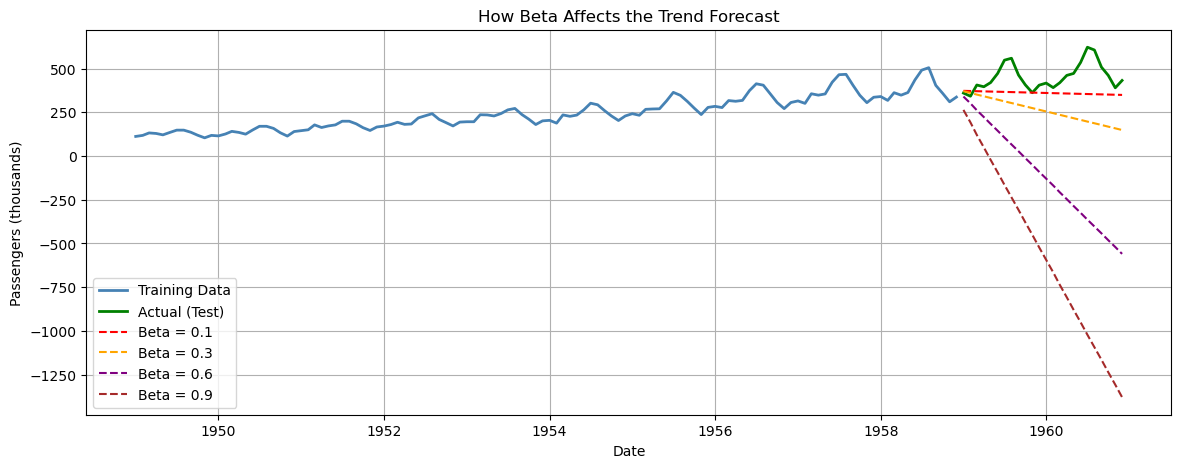

In [15]:
# Fit Double Exponential Smoothing with different beta values
# trend='add' means we model an additive trend (a straight line going up or down)

# Step 1 — Choose the beta values we want to test
betas = [0.1, 0.3, 0.6, 0.9]
colors = ['red', 'orange', 'purple', 'brown']

# Step 2 — Set up the chart and plot the real data
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['Passengers'], label='Training Data', color='steelblue', linewidth=2)
plt.plot(test.index, test['Passengers'], label='Actual (Test)', color='green', linewidth=2)

# Step 3 — Loop through each beta and add a forecast line to the chart
# Beta controls how strongly the model reacts to changes in trend
# High beta = reacts fast, Low beta = stays smooth

for i in range(len(betas)):
    beta = betas[i]
    color = colors[i]

    # Build the model with an additive trend
    double_model = ExponentialSmoothing(train['Passengers'], trend='add')

    # Fit with a fixed alpha=0.3 so only beta changes between runs
    double_fit = double_model.fit(
        smoothing_level=0.3,
        smoothing_trend=beta,
        optimized=False
    )

    # Forecast the test period
    double_preds = double_fit.forecast(steps=len(test))

    # Add this forecast to the chart
    plt.plot(test.index, double_preds, label='Beta = ' + str(beta), color=color, linestyle='--')

# Step 4 — Add labels and display the chart
plt.title('How Beta Affects the Trend Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True)
plt.show()

# Key difference from SES: the forecasts now slope upward!
# High beta → steep slope (the model reacts to very recent trend changes)
# Low beta  → gentle slope (the model uses a long-run average trend)
# But notice: forecasts are still smooth lines — no seasonal bumps yet

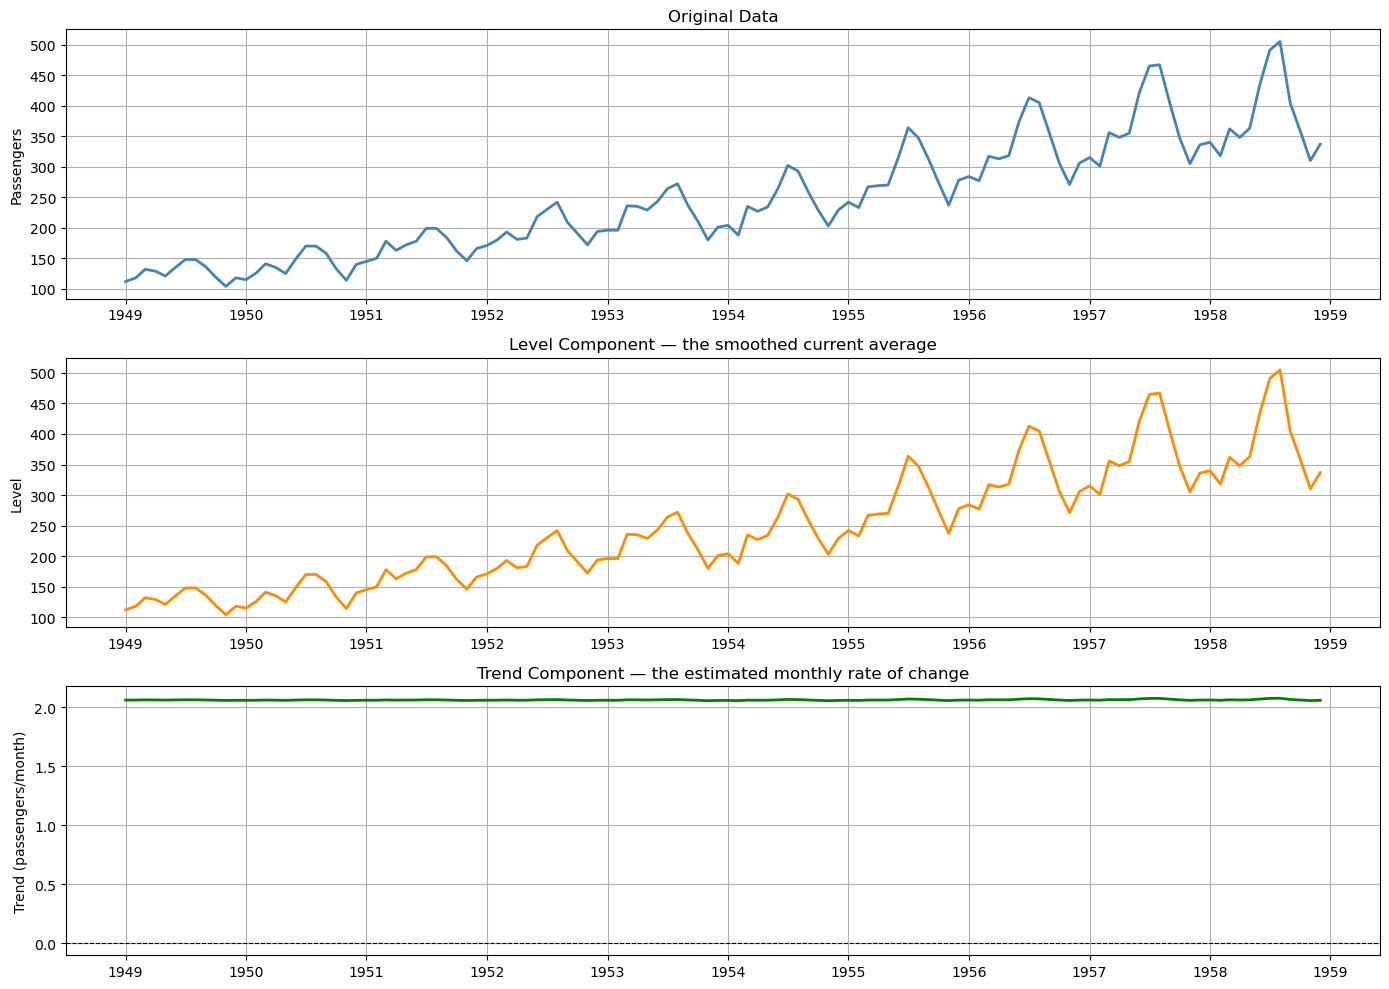

Smoothing parameters chosen automatically:
  Alpha (level): 0.995
  Beta  (trend): 0.0001


In [16]:
# Show what happens to Level and Trend components over time

double_model = ExponentialSmoothing(train['Passengers'], trend='add')
double_fit = double_model.fit(optimized=True)

# Extract the level and trend components from the fitted model
level  = double_fit.level
trend  = double_fit.trend

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original data
axes[0].plot(train.index, train['Passengers'], color='steelblue', linewidth=2)
axes[0].set_title('Original Data')
axes[0].set_ylabel('Passengers')
axes[0].grid(True)

# Level component
axes[1].plot(train.index, level, color='darkorange', linewidth=2)
axes[1].set_title('Level Component — the smoothed current average')
axes[1].set_ylabel('Level')
axes[1].grid(True)

# Trend component
axes[2].plot(train.index, trend, color='green', linewidth=2)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Trend Component — the estimated monthly rate of change')
axes[2].set_ylabel('Trend (passengers/month)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("Smoothing parameters chosen automatically:")
print("  Alpha (level):", round(double_fit.params['smoothing_level'], 4))
print("  Beta  (trend):", round(double_fit.params['smoothing_trend'], 4))

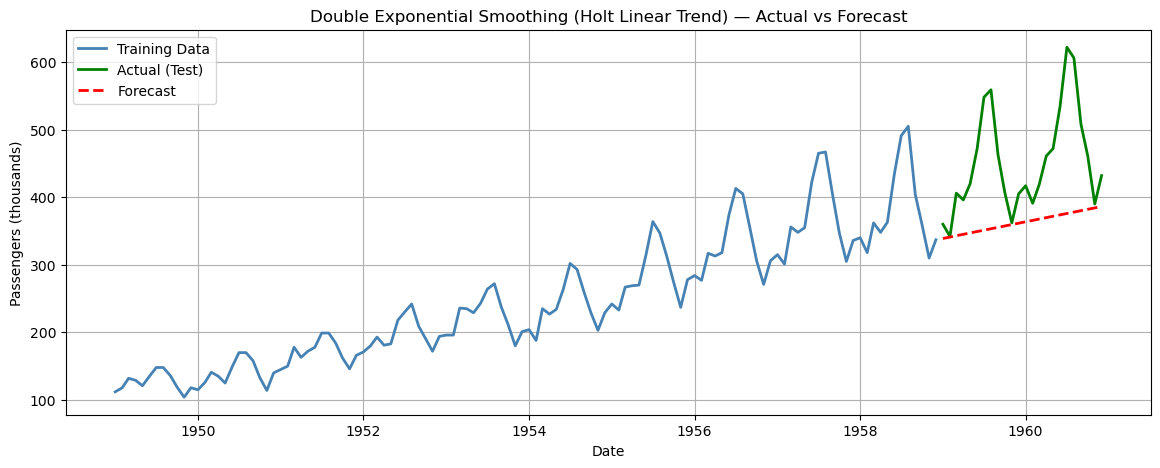

Results for: Double Exponential Smoothing (Holt Linear Trend)
  R² Score: -1.3305   (closer to 1.0 is better)
  MAE:      89.65 thousand passengers
  Error %:  19.82 % of average actual



In [17]:
# Evaluate Double Exponential Smoothing with automatic parameter selection

double_auto = ExponentialSmoothing(train['Passengers'], trend='add')
double_auto_fit = double_auto.fit(optimized=True)
double_preds = double_auto_fit.forecast(steps=len(test))

evaluate('Double Exponential Smoothing (Holt Linear Trend)', train['Passengers'], test['Passengers'], double_preds)

# Much better than SES — the forecast now slopes upward following the trend
# But there are still no seasonal bumps in the forecast
# The model sees the upward direction but not the July peaks and January dips
# This is what Triple Exponential Smoothing (Holt-Winters) fixes next

---
## Part F — Triple Exponential Smoothing (Holt-Winters)

### The final piece: Seasonality
Double Exponential Smoothing handles level and trend.  
But our airline data also has a strong **seasonal pattern** — peaks every summer.

**Triple Exponential Smoothing** (known as the **Holt-Winters** method) adds a third  
smoothing equation to track the **seasonal component**.

It now has **three components**:

| Component | What it tracks | Smoothing parameter |
|---|---|---|
| **Level (ℓ)** | The current average value | Alpha (α) |
| **Trend (b)** | The direction and speed of change | Beta (β) |
| **Seasonal (s)** | The seasonal adjustment for each period | Gamma (γ) |

**Forecast formula:**  
Forecast(t+h) = (Level + h × Trend) + Seasonal adjustment for that month

### Additive vs Multiplicative Seasonality

There are two ways to model seasonality:

| Type | When to use | How it works |
|---|---|---|
| **Additive** | Seasonal swings stay the same size | Adds a fixed amount each season |
| **Multiplicative** | Seasonal swings grow larger over time | Multiplies by a seasonal factor |

For our airline data, the summer peaks get **bigger every year** — so multiplicative is the right choice.

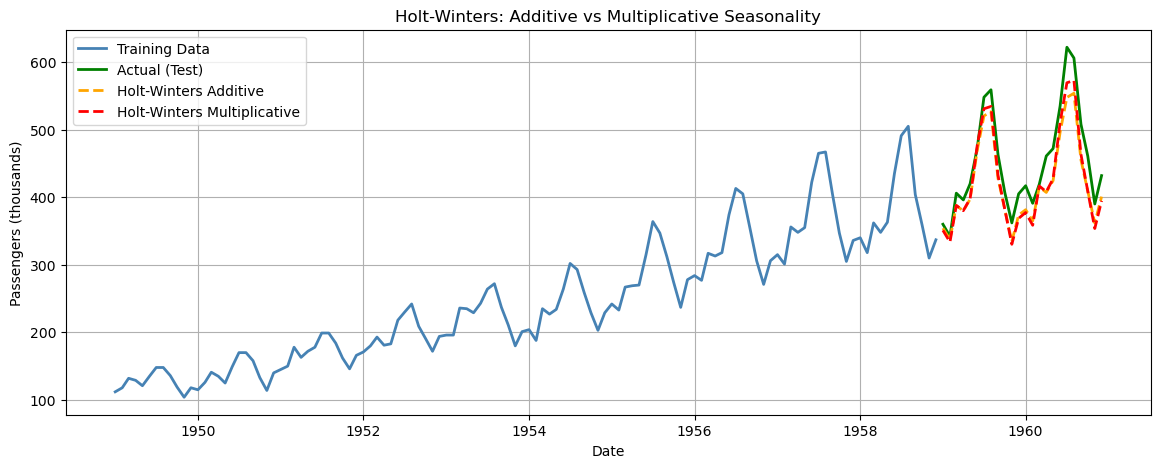

In [18]:
# First: compare additive vs multiplicative seasonality visually

model_add = ExponentialSmoothing(
    train['Passengers'],
    trend='add',
    seasonal='add',      # seasonal swings are a fixed size
    seasonal_periods=12  # one cycle = 12 months
)
fit_add = model_add.fit(optimized=True)
preds_add = fit_add.forecast(steps=len(test))

model_mul = ExponentialSmoothing(
    train['Passengers'],
    trend='add',
    seasonal='mul',      # seasonal swings grow proportionally
    seasonal_periods=12
)
fit_mul = model_mul.fit(optimized=True)
preds_mul = fit_mul.forecast(steps=len(test))

plt.figure(figsize=(14, 5))
plt.plot(train.index, train['Passengers'], label='Training Data', color='steelblue', linewidth=2)
plt.plot(test.index, test['Passengers'], label='Actual (Test)', color='green', linewidth=2)
plt.plot(test.index, preds_add, label='Holt-Winters Additive', color='orange', linewidth=2, linestyle='--')
plt.plot(test.index, preds_mul, label='Holt-Winters Multiplicative', color='red', linewidth=2, linestyle='--')
plt.title('Holt-Winters: Additive vs Multiplicative Seasonality')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True)
plt.show()

# Multiplicative (red) tracks the growing peaks more accurately
# Additive (orange) underestimates the peaks because it assumes fixed-size swings

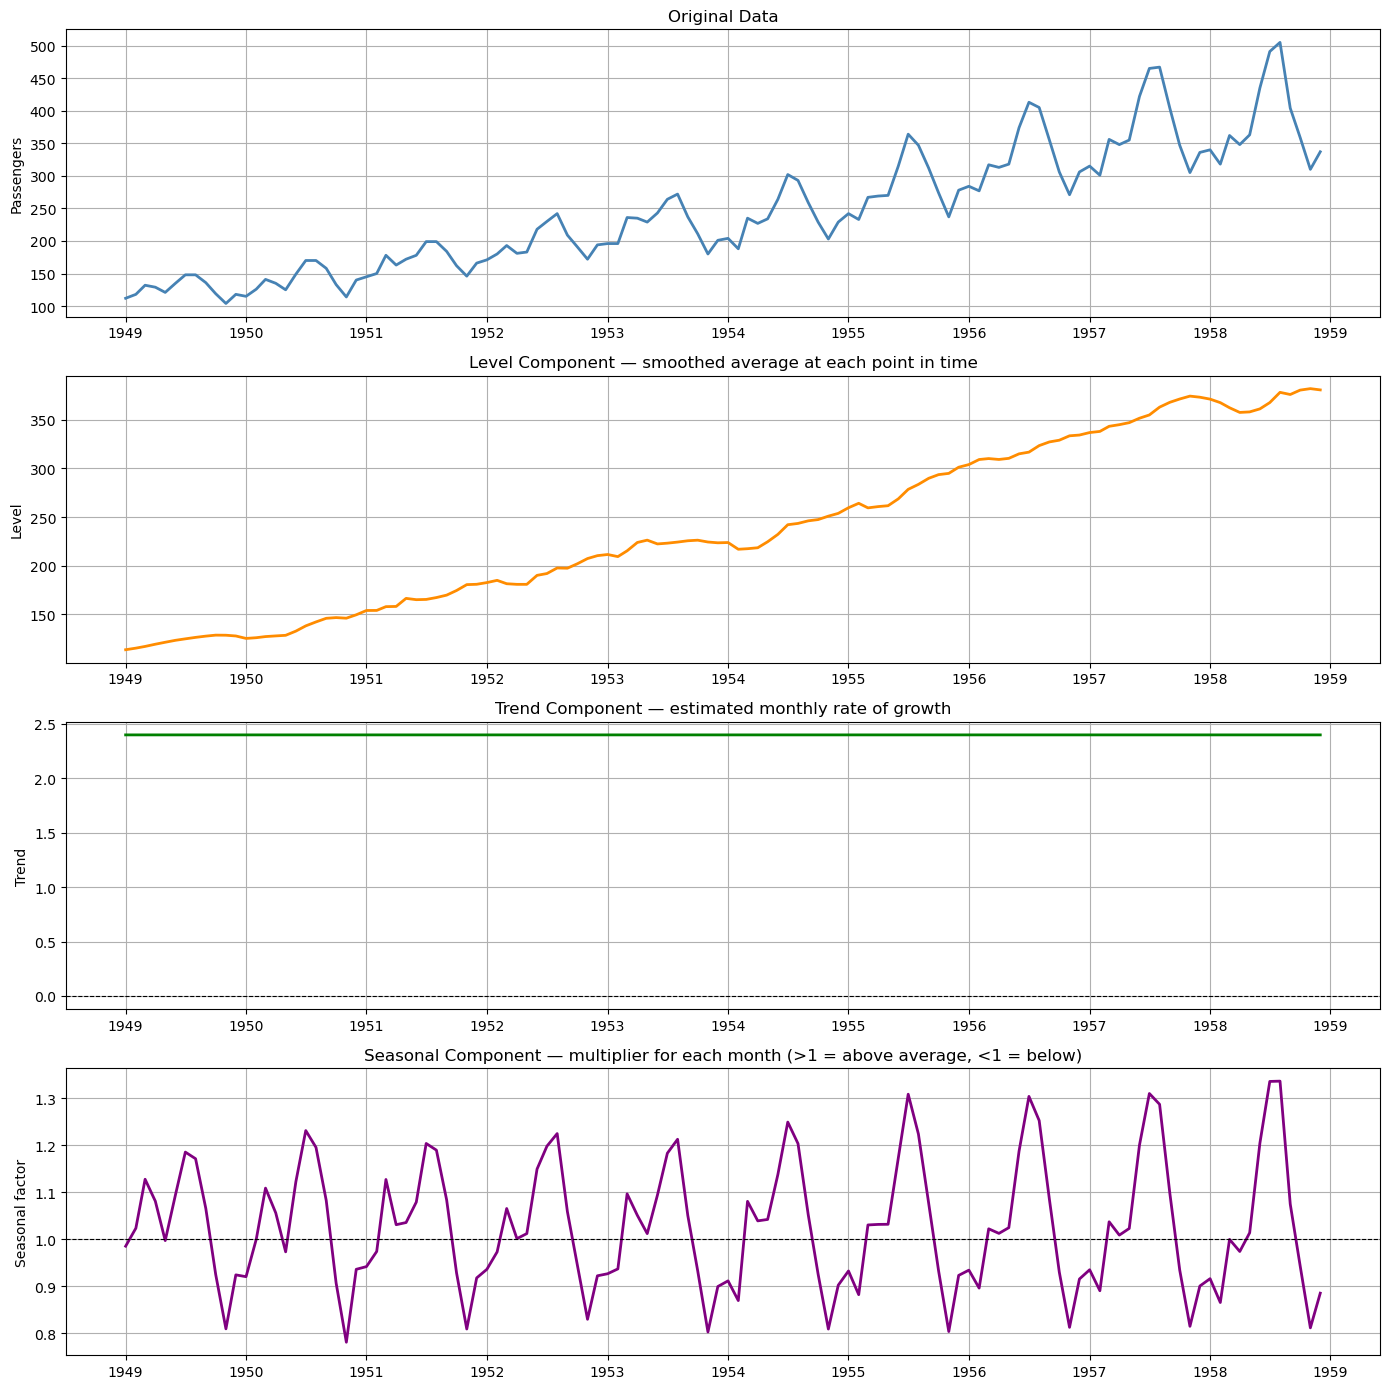

The seasonal component shows which months are above/below average:
  Values above 1.0 = above-average months (e.g. summer peaks)
  Values below 1.0 = below-average months (e.g. winter dips)


In [19]:
# Show all three components of the Holt-Winters model separately

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Original data
axes[0].plot(train.index, train['Passengers'], color='steelblue', linewidth=2)
axes[0].set_title('Original Data')
axes[0].set_ylabel('Passengers')
axes[0].grid(True)

# Level component
axes[1].plot(train.index, fit_mul.level, color='darkorange', linewidth=2)
axes[1].set_title('Level Component — smoothed average at each point in time')
axes[1].set_ylabel('Level')
axes[1].grid(True)

# Trend component
axes[2].plot(train.index, fit_mul.trend, color='green', linewidth=2)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Trend Component — estimated monthly rate of growth')
axes[2].set_ylabel('Trend')
axes[2].grid(True)

# Seasonal component
axes[3].plot(train.index, fit_mul.season, color='purple', linewidth=2)
axes[3].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[3].set_title('Seasonal Component — multiplier for each month (>1 = above average, <1 = below)')
axes[3].set_ylabel('Seasonal factor')
axes[3].grid(True)

plt.tight_layout()
plt.show()

print("The seasonal component shows which months are above/below average:")
print("  Values above 1.0 = above-average months (e.g. summer peaks)")
print("  Values below 1.0 = below-average months (e.g. winter dips)")

---
## Part G — Compare All Methods Side by Side

Now we put all six methods on one chart and one table to see the full progression clearly.

In [ ]:
# Collect all forecasts into one dictionary for comparison

forecasts = {}

# 1. Naive
last_val = train['Passengers'].iloc[-1]
forecasts['1. Naive'] = pd.Series([last_val] * len(test), index=test.index)

# 2. Simple Average
avg_val = train['Passengers'].mean()
forecasts['2. Simple Average'] = pd.Series([avg_val] * len(test), index=test.index)

# 3. Moving Average (window=12)
ma_val = train['Passengers'].iloc[-12:].mean()
forecasts['3. Moving Avg (12)'] = pd.Series([ma_val] * len(test), index=test.index)

# 4. Simple Exponential Smoothing
ses_fit = SimpleExpSmoothing(train['Passengers']).fit(optimized=True)
forecasts['4. Simple Exp Smoothing'] = ses_fit.forecast(steps=len(test))

# 5. Double Exponential Smoothing
double_fit = ExponentialSmoothing(train['Passengers'], trend='add').fit(optimized=True)
forecasts['5. Double Exp Smoothing'] = double_fit.forecast(steps=len(test))

# 6. Holt-Winters (Triple)
hw_fit = ExponentialSmoothing(train['Passengers'], trend='add', seasonal='mul', seasonal_periods=12).fit(optimized=True)
forecasts['6. Holt-Winters (Triple)'] = hw_fit.forecast(steps=len(test))

print("All forecasts ready for comparison.")

In [ ]:
# Plot all methods on one chart

plt.figure(figsize=(16, 7))
plt.plot(train.index, train['Passengers'], label='Training Data', color='steelblue', linewidth=2.5)
plt.plot(test.index, test['Passengers'], label='Actual (Test)', color='black', linewidth=2.5)

line_styles = ['--', '--', '--', '--', '--', '--']
colors = ['grey', 'orange', 'brown', 'purple', 'green', 'red']

for (name, preds), ls, color in zip(forecasts.items(), line_styles, colors):
    plt.plot(test.index, preds, label=name, linestyle=ls, color=color, linewidth=1.8)

plt.title('All Forecasting Methods — Side by Side Comparison')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Score all methods and build a comparison table

results = []

for name, preds in forecasts.items():
    r2  = r2_score(test['Passengers'], preds)
    mae = mean_absolute_error(test['Passengers'], preds)
    pct = (mae / test['Passengers'].mean()) * 100

    results.append({
        'Method': name,
        'R²': round(r2, 4),
        'MAE (thousands)': round(mae, 2),
        'Error %': round(pct, 2)
    })

results_df = pd.DataFrame(results)

print("Performance Comparison — All Methods:")
print()
print(results_df.to_string(index=False))
print()
print("Best R² :", results_df.loc[results_df['R²'].idxmax(), 'Method'])
print("Best MAE:", results_df.loc[results_df['MAE (thousands)'].idxmin(), 'Method'])

---
## Summary — What We Learned

### The progression

Each method we built was one step smarter than the one before it:

| Method | What it adds | Limitation it fixes |
|---|---|---|
| Naive | Nothing — repeat last value | Baseline only |
| Simple Average | Uses all history | Naive ignores history |
| Moving Average | Focuses on recent data | Simple avg weights old data equally |
| Simple Exp Smoothing (α) | Decaying weights — recent data counts more | Moving avg uses fixed equal weights |
| Double Exp Smoothing (α, β) | Adds a **Trend** component | SES cannot project a slope |
| Holt-Winters / Triple (α, β, γ) | Adds a **Seasonal** component | Double ES ignores repeating patterns |

### The three smoothing parameters

| Parameter | Controls | Effect of high value | Effect of low value |
|---|---|---|---|
| **Alpha (α)** | Level smoothing | Reacts fast to recent changes | Stable, slow to react |
| **Beta (β)** | Trend smoothing | Trend changes quickly | Trend is stable |
| **Gamma (γ)** | Seasonal smoothing | Seasonal pattern updates fast | Seasonal pattern is fixed |

### When to use each method

- **No trend, no seasonality** → Simple Exponential Smoothing  
- **Trend but no seasonality** → Double Exponential Smoothing (Holt's Linear)  
- **Trend AND seasonality** → Holt-Winters (Triple Exponential Smoothing)  
- **Additive vs Multiplicative**: use multiplicative when seasonal swings grow over time